---
## A — Why Linear Regression Fails on Curves

Linear Regression assumes: **output = straight line from inputs.**

But what if the true relationship is curved? Like:
- A ball thrown in the air (parabola)
- Salary vs years of experience (levels off)
- Temperature vs crop yield (too cold = bad, too hot = bad, sweet spot in the middle)

If you force a straight line through curved data, your model will be systematically wrong — no matter how much data you give it. This is called **underfitting**.

We need a model that can bend.

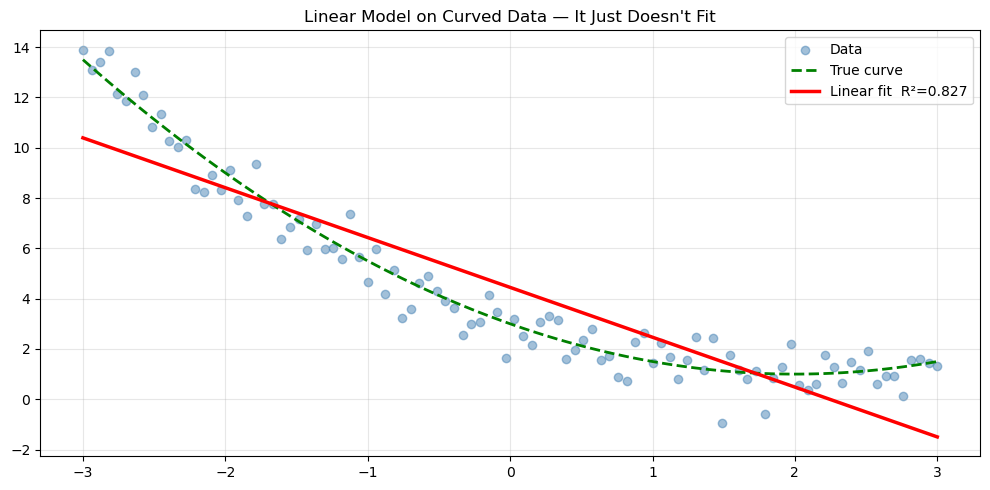

R² of linear model: 0.8269  — poor because curve ≠ line


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

# Curved data: y = 0.5x^2 - 2x + 3 + noise
X = np.linspace(-3, 3, 100)
y_true = 0.5 * X**2 - 2 * X + 3
y = y_true + np.random.randn(100) * 0.8

# Fit a linear model
lin_model = LinearRegression()
lin_model.fit(X.reshape(-1, 1), y)
y_lin_pred = lin_model.predict(X.reshape(-1, 1))

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(X, y, alpha=0.5, color='steelblue', label='Data')
plt.plot(X, y_true, 'g--', linewidth=2, label='True curve')
plt.plot(X, y_lin_pred, 'r-', linewidth=2.5, label=f'Linear fit  R²={r2_score(y, y_lin_pred):.3f}')
plt.title("Linear Model on Curved Data — It Just Doesn't Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R² of linear model: {r2_score(y, y_lin_pred):.4f}  — poor because curve ≠ line")

---
## B — What Polynomial Regression Actually Does

**Key insight:** Polynomial Regression is still just Linear Regression.

We don't change the model. We change the **features** by adding powers of $x$:

$$\text{Original:} \quad \hat{y} = w_1 x + b$$

$$\text{Degree 2:} \quad \hat{y} = w_1 x + w_2 x^2 + b$$

$$\text{Degree 3:} \quad \hat{y} = w_1 x + w_2 x^2 + w_3 x^3 + b$$

We just create extra feature columns ($x^2$, $x^3$, ...) and pass them to Linear Regression.
The model is still fitting a hyperplane — just in a higher-dimensional feature space.

**The degree** = how many terms we add = how curvy the fit can be.

---
## C — Feature Transformation: Turning $x$ into $[x, x^2, x^3, \ldots]$

This is the core trick. We manually (or with sklearn) expand our feature matrix.

Example for a single data point $x = 2$ and degree 3:

$$[x] = [2] \quad \rightarrow \quad [x, x^2, x^3] = [2, 4, 8]$$

Then we fit `LinearRegression` on these expanded features — it learns weights for each column.

In [4]:
def make_poly_features(X, degree):
    """
    Manually build polynomial feature matrix.
    X: 1D array of shape (n,)
    Returns: matrix of shape (n, degree)  — columns: x^1, x^2, ..., x^degree
    """
    return np.column_stack([X**d for d in range(1, degree + 1)])

# Demo
x_sample = np.array([1.0, 2.0, 3.0])
X_poly3 = make_poly_features(x_sample, degree=3)

print("x values:         ", x_sample)
print("Poly features (degree=3):")
print("  x^1:", X_poly3[:, 0])
print("  x^2:", X_poly3[:, 1])
print("  x^3:", X_poly3[:, 2])
print(f"\nMatrix shape: {X_poly3.shape}")
print("Each row = one data point with expanded features.")

x values:          [1. 2. 3.]
Poly features (degree=3):
  x^1: [1. 2. 3.]
  x^2: [1. 4. 9.]
  x^3: [ 1.  8. 27.]

Matrix shape: (3, 3)
Each row = one data point with expanded features.


---
## D — Underfitting vs Overfitting: The Core Tradeoff

This is THE most important concept in all of machine learning.

| Degree | What happens | Name |
|--------|-------------|------|
| Too low (e.g. 1) | Model too simple, misses the real pattern | **Underfitting** (high bias) |
| Just right (e.g. 2 for a parabola) | Captures the pattern, generalizes well | **The sweet spot** |
| Too high (e.g. 15) | Model memorizes the training data, fails on new data | **Overfitting** (high variance) |

The goal is always to find the sweet spot — complex enough to learn, simple enough to generalize.

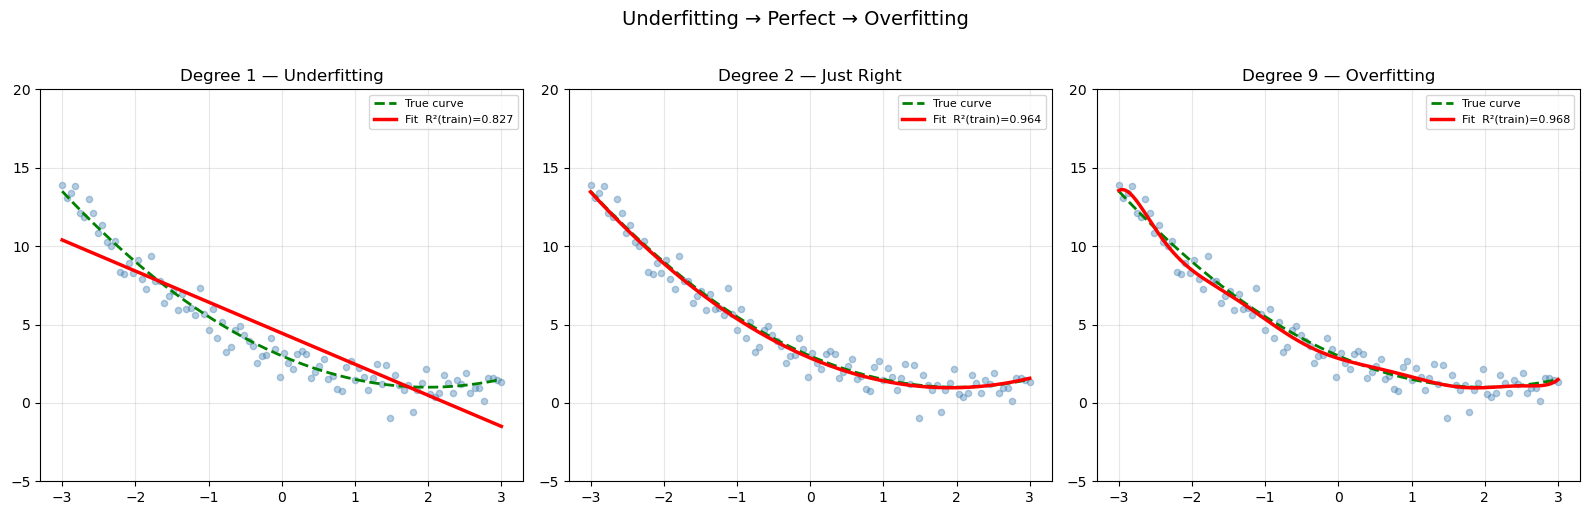

In [5]:
# Visual proof of underfitting vs overfitting
degrees = [1, 2, 9]
titles  = ['Degree 1 — Underfitting', 'Degree 2 — Just Right', 'Degree 9 — Overfitting']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
X_plot = np.linspace(-3, 3, 300)

for ax, deg, title in zip(axes, degrees, titles):
    X_feat  = make_poly_features(X, deg)
    X_plot_feat = make_poly_features(X_plot, deg)

    model = LinearRegression()
    model.fit(X_feat, y)
    y_plot = model.predict(X_plot_feat)
    r2 = r2_score(y, model.predict(X_feat))

    ax.scatter(X, y, alpha=0.4, color='steelblue', s=20)
    ax.plot(X_plot, y_true_plot := 0.5 * X_plot**2 - 2 * X_plot + 3,
            'g--', linewidth=2, label='True curve')
    ax.plot(X_plot, y_plot, 'r-', linewidth=2.5, label=f'Fit  R²(train)={r2:.3f}')
    ax.set_ylim(-5, 20)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Underfitting → Perfect → Overfitting", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## E — From Scratch: Full Polynomial Regression

Using our `make_poly_features` function + plain `LinearRegression` from scratch (the same one we can build with NumPy — here we use the Normal Equation directly).

Learned weights (degree=2):
  intercept (b) : 2.8671  (true: ~3)
  w1 (x)        : -1.9816  (true: -2)
  w2 (x²)       : 0.5163  (true: 0.5)


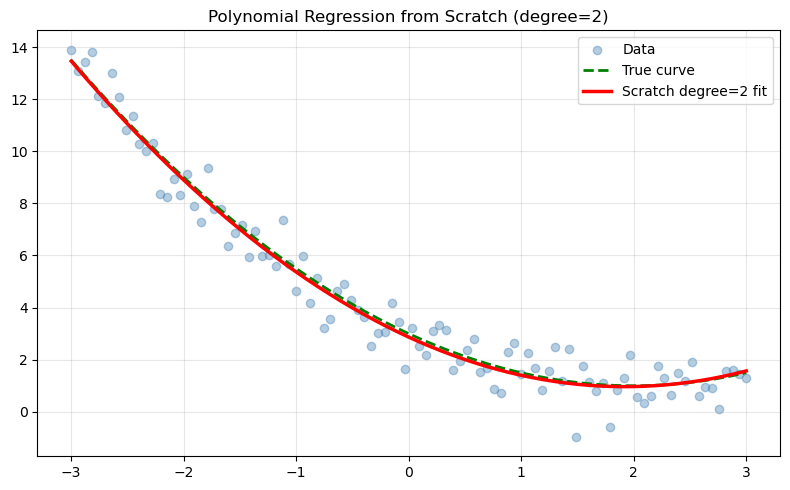

In [6]:
def poly_regression_scratch(X_train, y_train, X_pred, degree):
    """
    Polynomial regression from scratch.
    Uses Normal Equation: w = (X^T X)^-1 X^T y
    """
    # Build feature matrices
    Phi_train = np.column_stack([np.ones(len(X_train))] + [X_train**d for d in range(1, degree + 1)])
    Phi_pred  = np.column_stack([np.ones(len(X_pred))]  + [X_pred**d  for d in range(1, degree + 1)])

    # Normal Equation
    w = np.linalg.lstsq(Phi_train, y_train, rcond=None)[0]  # lstsq = numerically stable version

    return Phi_pred @ w, w

# Test with degree=2 (should recover our parabola)
X_plot = np.linspace(-3, 3, 300)
y_plot_scratch, weights = poly_regression_scratch(X, y, X_plot, degree=2)

print("Learned weights (degree=2):")
print(f"  intercept (b) : {weights[0]:.4f}  (true: ~3)")
print(f"  w1 (x)        : {weights[1]:.4f}  (true: -2)")
print(f"  w2 (x²)       : {weights[2]:.4f}  (true: 0.5)")

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.4, color='steelblue', label='Data')
plt.plot(X_plot, 0.5 * X_plot**2 - 2 * X_plot + 3, 'g--', linewidth=2, label='True curve')
plt.plot(X_plot, y_plot_scratch, 'r-', linewidth=2.5, label='Scratch degree=2 fit')
plt.title("Polynomial Regression from Scratch (degree=2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## F — Sklearn: `PolynomialFeatures` + Pipeline

In practice, use sklearn's `PolynomialFeatures` transformer inside a `Pipeline`.
A Pipeline chains steps so you don't have to manually transform train/test separately (which is a common bug source).

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X.reshape(-1, 1), y, test_size=0.2, random_state=42
)

# Build pipeline: expand features → fit linear model
poly_pipe = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])

poly_pipe.fit(X_tr, y_tr)
y_te_pred = poly_pipe.predict(X_te)

print(f"R² on test set (degree=2): {r2_score(y_te, y_te_pred):.4f}")
print()

# Show what PolynomialFeatures produces
pf = PolynomialFeatures(degree=2, include_bias=False)
sample = np.array([[2.0]])
print("Input:  ", sample)
print("Output: ", pf.fit_transform(sample))
print("Feature names:", pf.fit(X_tr).get_feature_names_out())

R² on test set (degree=2): 0.9755

Input:   [[2.]]
Output:  [[2. 4.]]
Feature names: ['x0' 'x0^2']


---
## G — Choosing the Right Degree: Validation Curves

We train models of degree 1 through 10 and check **train R²** vs **test R²**.

- If train R² is low → underfitting (increase degree)
- If train R² is high but test R² is low → overfitting (decrease degree)
- If both are high → sweet spot ✓

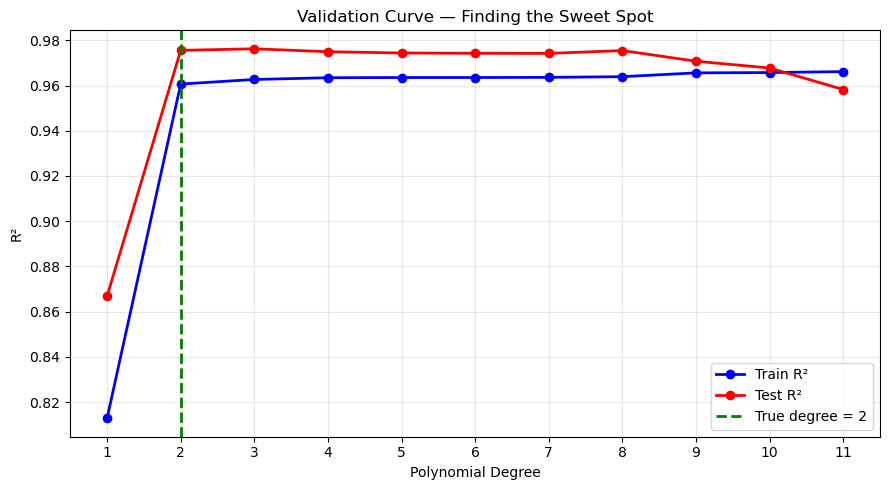

Best degree by test R²: 3
Train R² keeps rising (model memorizes more), but test R² peaks and then drops.


In [8]:
train_r2_scores = []
test_r2_scores  = []
degrees = range(1, 12)

for deg in degrees:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=deg, include_bias=False)),
        ('model', LinearRegression())
    ])
    pipe.fit(X_tr, y_tr)
    train_r2_scores.append(r2_score(y_tr, pipe.predict(X_tr)))
    test_r2_scores.append(r2_score(y_te, pipe.predict(X_te)))

plt.figure(figsize=(9, 5))
plt.plot(degrees, train_r2_scores, 'b-o', linewidth=2, label='Train R²')
plt.plot(degrees, test_r2_scores,  'r-o', linewidth=2, label='Test R²')
plt.axvline(x=2, color='green', linestyle='--', linewidth=2, label='True degree = 2')
plt.xlabel("Polynomial Degree")
plt.ylabel("R²")
plt.title("Validation Curve — Finding the Sweet Spot")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(list(degrees))
plt.tight_layout()
plt.show()

best_deg = list(degrees)[test_r2_scores.index(max(test_r2_scores))]
print(f"Best degree by test R²: {best_deg}")
print("Train R² keeps rising (model memorizes more), but test R² peaks and then drops.")

---
## H — Bias-Variance Tradeoff Explained Visually

The gap between train and test R² tells you everything:

```
             Underfit         Sweet Spot         Overfit
                |                  |                |
Train R²:    LOW ─────────────── HIGH ──────────── HIGH
Test R²:     LOW ─────────────── HIGH ──────── LOW (diverges)
                                                    ^
                                              Gap appears here
```

- **High Bias** (underfit): model is too simple, gets both wrong
- **High Variance** (overfit): model is too complex, memorizes noise, fails to generalize
- **Sweet spot**: low bias AND low variance — generalizes well

**In practice:** always evaluate on held-out test data. Never trust train R² alone.

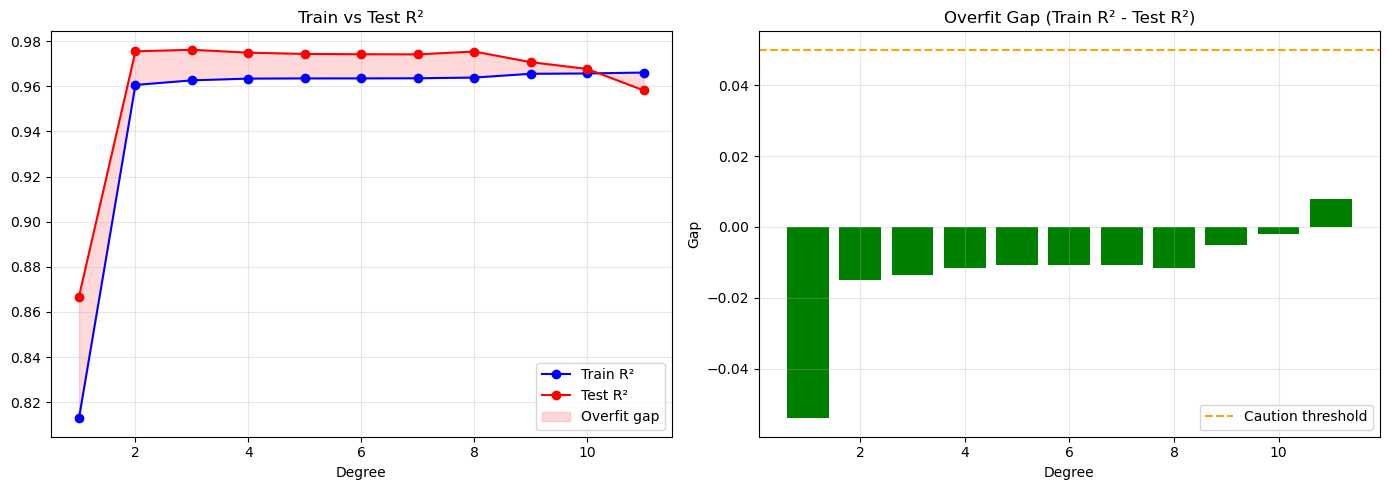

In [9]:
# Visualize the gap = overfitting risk
gap = np.array(train_r2_scores) - np.array(test_r2_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degrees, train_r2_scores, 'b-o', label='Train R²')
axes[0].plot(degrees, test_r2_scores, 'r-o', label='Test R²')
axes[0].fill_between(degrees, train_r2_scores, test_r2_scores,
                     alpha=0.15, color='red', label='Overfit gap')
axes[0].set_title("Train vs Test R²")
axes[0].set_xlabel("Degree")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(degrees, gap, color=['green' if g < 0.05 else 'orange' if g < 0.15 else 'red' for g in gap])
axes[1].axhline(y=0.05, color='orange', linestyle='--', linewidth=1.5, label='Caution threshold')
axes[1].set_title("Overfit Gap (Train R² - Test R²)")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Gap")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## I — Real-World Tips

**1. Always start with degree=1 (linear) first.**
If linear already gives R²=0.95, you don't need polynomials.

**2. Feature scaling matters for high degrees.**
$x^{10}$ for large $x$ creates huge numbers. Use `StandardScaler` before `PolynomialFeatures`.

**3. Use cross-validation, not a single train/test split.**
A single split can be lucky or unlucky. Cross-validation gives a more reliable estimate.

**4. Consider regularization (Ridge/Lasso) instead of limiting degree.**
Regularization lets you use a higher-degree polynomial but penalizes large weights — preventing overfitting while keeping flexibility. (That's the next notebook!)

In [10]:
# Tip: feature scaling + polynomial + cross-validation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('model',  LinearRegression())
])

cv_scores = cross_val_score(best_pipe, X.reshape(-1, 1), y, cv=5, scoring='r2')
print("5-Fold Cross-Validation R² scores:", cv_scores.round(4))
print(f"Mean R²: {cv_scores.mean():.4f}  ± {cv_scores.std():.4f}")
print("\nUsing CV gives a much more trustworthy estimate than a single split.")

5-Fold Cross-Validation R² scores: [ 0.846   0.7338  0.3966  0.0732 -0.6876]
Mean R²: 0.2724  ± 0.5511

Using CV gives a much more trustworthy estimate than a single split.


---
## 🏁 Summary

```
Linear can't curve → Add x², x³... → It's still LinearRegression under the hood
```

| What you learned | Key takeaway |
|-----------------|-------------|
| Why poly regression | Linear model fails when relationship is curved |
| The trick | Add $x^2, x^3, \ldots$ as new features — model stays linear |
| Underfitting | Degree too low → model misses the pattern |
| Overfitting | Degree too high → model memorizes noise, fails on new data |
| Validation curve | Plot train vs test R² across degrees to find the sweet spot |
| Bias-Variance | The fundamental tradeoff in all of ML |
| Sklearn | `PolynomialFeatures` + `Pipeline` + `cross_val_score` |

### What's Next?
- **Ridge / Lasso Regression** — fight overfitting with regularization (instead of limiting degree)
- **Logistic Regression** — when your target is a class label, not a number